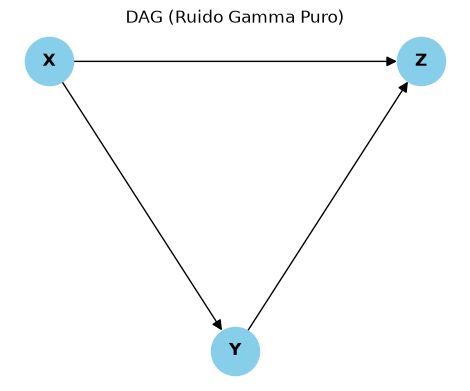


######################################################################
INICIANDO EXPERIMENTO 1 PARA SEMILLA = 42
######################################################################

INICIANDO EXPERIMENTO PARA N = 100
 -> Entrenando MSE para N=100 y semilla=42...
Using device: cpu
Early stopping at step 63
Using device: cpu
Early stopping at step 45
 -> Entrenando HSIC para N=100 y semilla=42...
Using device: cpu
Early stopping at step 35
Using device: cpu
Early stopping at step 81
 -> Entrenando HYBRID_ALPHA0.1 para N=100 y semilla=42...
Using device: cpu
Early stopping at step 48
Using device: cpu
Early stopping at step 82
 -> Entrenando HYBRID_ALPHA0.2 para N=100 y semilla=42...
Using device: cpu
Early stopping at step 45
Using device: cpu
Early stopping at step 84
 -> Entrenando HYBRID_ALPHA0.3 para N=100 y semilla=42...
Using device: cpu
Early stopping at step 45
Using device: cpu
Early stopping at step 45
 -> Entrenando HYBRID_ALPHA0.4 para N=100 y semilla=42...
Using device: 

,Experiment,Seed,Loss,Conf,Alpha,Beta,N,MSE Y,MAE Y,"HSIC(Y,X)",MSE Z,MAE Z,"HSIC(Z,X)","HSIC(Z,Y)",dHSIC Total,MMD,RF Acc
1,1,42,hsic,HSIC,0.0,1.0,100,2.00062,0.73333,0.30392,8.39849,1.31387,0.36157,0.11259,0.00686,0.03126,0.70000
12,1,42,hsic,HSIC,0.0,1.0,300,1.79450,1.06042,0.18836,7.38714,1.27646,0.29844,0.09167,0.00454,0.07343,0.73333
23,1,42,hsic,HSIC,0.0,1.0,500,1.58853,0.99096,0.14441,5.77246,1.18167,0.06404,0.03288,0.00407,0.12251,0.77000
2,1,42,hybrid,HYBRID_ALPHA0.1_BETA0.9,0.1,0.9,100,2.07712,0.75076,0.31896,8.28753,1.30945,0.36160,0.11273,0.00629,0.03279,0.70000
3,1,42,hybrid,HYBRID_ALPHA0.2_BETA0.8,0.2,0.8,100,2.13826,0.74264,0.31172,8.27687,1.31097,0.36770,0.11540,0.00629,0.03289,0.70000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
328,10,51,hybrid,HYBRID_ALPHA0.8_BETA0.2,0.8,0.2,500,0.47309,0.45546,0.14760,0.69348,0.60640,0.01156,0.03412,0.00142,0.01632,0.77000
329,10,51,hybrid,HYBRID_ALPHA0.9_BETA0.1,0.9,0.1,500,0.47446,0.45789,0.15583,0.69691,0.60584,0.01565,0.03455,0.00134,0.01651,0.72000
297,10,51,mse,MSE,1.0,0.0,100,3.50602,0.82432,0.38905,1.78670,0.90299,0.18670,0.13720,0.00494,0.06328,0.65000
308,10,51,mse,MSE,1.0,0.0,300,0.56242,0.50697,0.12260,0.77837,0.65938,0.02880,0.11981,0.00261,0.02800,0.56667


In [1]:
# ==============================================================================
# BLOQUES 2 y 3 REESTRUCTURADOS: EVALUACIÓN MULTI-N CON MAE (CORREGIDO)
# ==============================================================================
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "..")))

import time
import numpy as np
import re
import pandas as pd
import networkx as nx
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from src.utils.metrics import HSIC, dHSIC, mmd, rf
from src.models.kan import hsic_loss, kan_model_mixed


# --- [PASO 1: DEFINICIÓN DE FUNCIONES AUXILIARES PARA EVITAR NAMEERROR] ---

def generate_synthetic_triangle_data_pure_gausian (num_samples=2000, seed=42, escala=1.0):
    """Genera el SCM No Lineal con ruido Gamma centrado (media 0, varianza escala**2)."""
    np.random.seed(seed)
    forma = 2.0  # asimetria = 2/sqrt(forma); con forma=1 la Gamma seria identica a la Exponencial
    theta, media_gamma = escala / np.sqrt(forma), np.sqrt(forma) * escala
    eps_X = np.random.gamma(shape=forma, scale=theta, size=num_samples) - media_gamma
    eps_Y = np.random.gamma(shape=forma, scale=theta, size=num_samples) - media_gamma
    eps_Z = np.random.gamma(shape=forma, scale=theta, size=num_samples) - media_gamma
    
    X = eps_X
    Y = 0.5 * (X ** 2) + np.sin(X) * eps_Y
    Z = 0.7 * X + 0.4 * (Y ** 2) - np.cos(Y) * eps_Z
    return pd.DataFrame({'X': X, 'Y': Y, 'Z': Z})

def crear_estructura_nodos(grafo, params_base, loss_name, alpha, beta, node_types, num_classes):
    """Empaqueta la configuración de pesos por nodo requerida por kan_model_mixed."""
    config_nodos = {}
    for nodo in grafo.nodes():
        nodo_params = params_base.copy()
        nodo_params['loss'] = loss_name
        nodo_params['alpha_weight'] = alpha
        nodo_params['beta_weight'] = beta
        nodo_params['node_types'] = node_types
        nodo_params['num_classes'] = num_classes
        config_nodos[nodo] = nodo_params
    return config_nodos

def preparar_residuo(res):
    """Convierte tensores de Torch o arrays a numpy array plano de forma segura."""
    if hasattr(res, 'detach'): res = res.detach()
    if hasattr(res, 'cpu'): res = res.cpu()
    return np.array(res).flatten()


# --- [PASO 2: CONFIGURACIÓN DEL EXPERIMENTO] ---

# Definimos los tamaños de muestra (N) que queremos auditar
valores_N_experimento = [100,300,500]
valores_alpha_candidatos = np.linspace(0.0, 1.0, num=11)
semillas_experimento = np.array([42, 43, 44, 45, 46, 47, 48, 49, 50, 51]) # Ejecutar el experimento con 10 semillas distintas

# Estructura del Grafo Causal Criterio
graph_triangle = nx.DiGraph([('X', 'Y'), ('X', 'Z'), ('Y', 'Z')])

# Mapeo de tipos continuos para la KAN
node_types = {'X': 'continuous', 'Y': 'continuous', 'Z': 'continuous'}
num_classes = {}

# Dibujar el DAG estructural para la documentación de tu TFM
pos = {'X': (0, 1), 'Y': (1, 0), 'Z': (2, 1)}
plt.figure(figsize=(4.5, 3.5))
nx.draw(graph_triangle, pos, with_labels=True, node_size=1200, node_color='skyblue', font_size=12, font_weight='bold', arrowsize=15)
plt.title("DAG (Ruido Gamma Puro)")
plt.show()

base_kan_params = {
    'hidden_dim': 5, 'batch_size': -1, 'grid': 5, 'k': 5, 'seed': 42,
    'lr': 0.002, 'early_stop': True, 'steps': 5000, 'lamb': 0.05,
    'lamb_entropy': 0.05, 'sparse_init': False, 'mult_kan': True,
    'try_gpu': False, 'verbose': 0
}

registros_tabla_final = []


# --- [PASO 3: BUCLE PRINCIPAL DE ENTRENAMIENTO Y EVALUACIÓN] ---

for experiment_id, seed in enumerate(semillas_experimento, start=1):
    print(f"\n" + "#"*70)
    print(f"INICIANDO EXPERIMENTO {experiment_id} PARA SEMILLA = {seed}")
    print("#"*70)

    for N_actual in valores_N_experimento:
        print(f"\n" + "="*70)
        print(f"INICIANDO EXPERIMENTO PARA N = {N_actual}")
        print("="*70)
        
        # 1. Generación de datos escalada al N actual
        data_triangle = generate_synthetic_triangle_data_pure_gausian(num_samples=N_actual, seed=seed, escala=1.0)
        factual_train_d, factual_eval_d = train_test_split(data_triangle, test_size=0.5, random_state=42)
        
        datos_reales_test = factual_eval_d[['X', 'Y', 'Z']].to_numpy()
        num_muestras_eval = len(factual_eval_d)
        
        # 2. Definición de las estrategias (Baselines + Híbridos)
        strategies = ['mse', 'hsic'] + [f"hybrid_alpha{round(a,2)}" for a in valores_alpha_candidatos if a != 0.0 and a != 1.0]
        
        for strategy_key in strategies:
            if strategy_key == "mse":
                strategy_name, alpha_val, beta_val = "mse", 1.0, 0.0
            elif strategy_key == "hsic":
                strategy_name, alpha_val, beta_val = "hsic", 0.0, 1.0
            else:
                strategy_name = "hybrid"
                alpha_val = round(float(re.findall(r"[-+]?\d*\.\d+|\\d+", strategy_key)[0]), 2)
                beta_val = round(1.0 - alpha_val, 2)
                
            # Llamada segura con argumentos locales pasados explícitamente
            params_estructurados = crear_estructura_nodos(
                graph_triangle, base_kan_params, strategy_name, alpha_val, beta_val, node_types, num_classes
            )
            
            print(f" -> Entrenando {strategy_key.upper()} para N={N_actual} y semilla={seed}...")
            model = kan_model_mixed(graph_triangle, params_estructurados)
            model.fit(data=factual_train_d)
            
            # 3. Diagnóstico en el conjunto de evaluación de este N
            conf_name = strategy_key.upper() if strategy_name != "hybrid" else f"HYBRID_ALPHA{alpha_val}_BETA{beta_val}"
            fila = {
                'Experiment': experiment_id,
                'Seed': seed,
                'Loss': strategy_name,
                'Conf': conf_name,
                'Alpha': alpha_val,
                'Beta': beta_val,
                'N': N_actual
            }
            
            try:
                if hasattr(model, 'get_residuals'):
                    residuos = model.get_residuals(factual_eval_d)
                    X_test = factual_eval_d['X'].to_numpy().flatten()
                    Y_test = factual_eval_d['Y'].to_numpy().flatten()
                    sistema_residuos = [X_test]
                    
                    if 'Y' in residuos and residuos['Y'] is not None:
                        rY = preparar_residuo(residuos['Y'])
                        sistema_residuos.append(rY)
                        fila['MSE Y'] = round(float(np.mean(rY**2)), 5)
                        fila['MAE Y'] = round(float(np.mean(np.abs(rY))), 5)
                        fila['HSIC(Y,X)'] = round(float(HSIC(rY, X_test)), 5)
                        
                    if 'Z' in residuos and residuos['Z'] is not None:
                        rZ = preparar_residuo(residuos['Z'])
                        sistema_residuos.append(rZ)
                        fila['MSE Z'] = round(float(np.mean(rZ**2)), 5)
                        fila['MAE Z'] = round(float(np.mean(np.abs(rZ))), 5)
                        fila['HSIC(Z,X)'] = round(float(HSIC(rZ, X_test)), 5)
                        fila['HSIC(Z,Y)'] = round(float(HSIC(rZ, Y_test)), 5)
                    
                    fila['dHSIC Total'] = round(float(max(0.0, dHSIC(*sistema_residuos))), 5)

                if hasattr(model, 'draw_samples'):
                    datos_gen = model.draw_samples(num_samples=num_muestras_eval)[['X', 'Y', 'Z']].to_numpy()
                    fila['MMD'] = round(float(max(0.0, mmd(datos_reales_test, datos_gen))), 5)
                    fila['RF Acc'] = round(float(rf(datos_reales_test, datos_gen)), 5)

            except Exception as e:
                print(f"   [Error en evaluación] {conf_name} con N={N_actual}: {e}")
                
            registros_tabla_final.append(fila)

# --- [PASO 4: CONSTRUCCIÓN DE LA TABLA MAESTRA] ---
df_final_multi_n = pd.DataFrame(registros_tabla_final)
df_final_multi_n['es_hibrido'] = df_final_multi_n['Conf'].str.contains('HYBRID')
df_final_multi_n = df_final_multi_n.sort_values(by=['Experiment', 'Seed', 'Loss', 'N', 'es_hibrido', 'Alpha', 'Beta'], ascending=[True, True, True, True, True, True, True])
# Reordenar columnas para mostrar primero experimento, semilla y función de pérdida
base_cols = ['Experiment', 'Seed', 'Loss', 'Conf', 'Alpha', 'Beta', 'N']
other_cols = [c for c in df_final_multi_n.columns if c not in base_cols + ['es_hibrido']]
df_final_multi_n = df_final_multi_n[base_cols + other_cols]

print("\n--- MATRIZ DE DIAGNÓSTICO MULTI-N FINALIZADA ---")
display(df_final_multi_n)

# --- [PASO 5: GUARDADO DE RESULTADOS EN CSV] ---
carpeta_tablas = "tablas"
ruta_archivo = os.path.join(carpeta_tablas, "aditivo_gamma.csv")

# Crear la carpeta si no existe
if not os.path.exists(carpeta_tablas):
    os.makedirs(carpeta_tablas)

# Guardar el DataFrame
df_final_multi_n.to_csv(ruta_archivo, index=False)

In [4]:
# ==============================================================================
# PASO 6: TABLA RESUMEN CON MEDIA Y DESVIACIÓN TÍPICA
# (Media ± Std para CADA combinación de Alpha/Beta a través de las 10 semillas)
# ==============================================================================
print("\n" + "="*100)
print("TABLA RESUMEN: MEDIA ± DESVIACIÓN TÍPICA PARA CADA COMBINACIÓN ALPHA-BETA (10 SEMILLAS)")
print("="*100)

# Identificar métricas numéricas (excluyendo metadatos)
cols_excluidas = {'Experiment', 'Seed', 'Loss', 'Conf', 'Alpha', 'Beta', 'N', 'es_hibrido'}
metricas_numericas = [col for col in df_final_multi_n.columns if col not in cols_excluidas]

# Procesar por tamaño de muestra (N) de forma independiente
for n_val in sorted(df_final_multi_n['N'].unique()):
    df_n_filtered = df_final_multi_n[df_final_multi_n['N'] == n_val].copy()
    
    print(f"\n\n{'#'*100}")
    print(f"# EXPERIMENTO: N = {n_val} MUESTRAS")
    print(f"{'#'*100}\n")
    
    # Agrupar por (Alpha, Beta) - esto captura cada combinación única
    resumen_por_config = []
    
    for (alpha_val, beta_val), group_config in df_n_filtered.groupby(['Alpha', 'Beta']):
        # group_config contiene las 10 repeticiones (semillas) para esta combinación
        
        fila_resumen = {
            'Alpha': alpha_val,
            'Beta': beta_val,
            'Loss': group_config['Loss'].iloc[0],  # La Loss es la misma para esta combinación
            'Conf': group_config['Conf'].iloc[0],  # Nombre de la configuración
            'Num_Seeds': len(group_config)  # Debe ser 10
        }
        
        # Para cada métrica, calcular media y std de las 10 semillas
        for metrica in metricas_numericas:
            media_metrica = group_config[metrica].mean()
            std_metrica = group_config[metrica].std()
            # Guardar como valores separados para CSV
            fila_resumen[f'{metrica}_mean'] = round(media_metrica, 5)
            fila_resumen[f'{metrica}_std'] = round(std_metrica, 5)
        
        resumen_por_config.append(fila_resumen)
    
    # Convertir a DataFrame
    df_resumen_n = pd.DataFrame(resumen_por_config)
    
    # Ordenar por Loss (mse, hsic, hybrid) y luego por Alpha descendente
    orden_loss = {'mse': 0, 'hsic': 1, 'hybrid': 2}
    df_resumen_n['loss_order'] = df_resumen_n['Loss'].map(orden_loss)
    df_resumen_n = df_resumen_n.sort_values(['loss_order', 'Alpha'], ascending=[True, False])
    df_resumen_n = df_resumen_n.drop('loss_order', axis=1)
    
    print(f"Tabla resumen para N={n_val}:\n")
    display(df_resumen_n)
    
    # Guardar cada tabla N en un CSV separado
    ruta_resumen_n = os.path.join("tablas", f"resumen_n_{n_val}_aditivo_gamma.csv")
    if not os.path.exists("tablas"):
        os.makedirs("tablas")
    df_resumen_n.to_csv(ruta_resumen_n, index=False)
    print(f"\n✓ Tabla resumen guardada en: {ruta_resumen_n}\n")

# Crear también una tabla consolidada con formato legible "media ± std"
print(f"\n\n{'='*100}")
print("FORMATO LEGIBLE: Media ± Std para cada métrica")
print(f"{'='*100}\n")

for n_val in sorted(df_final_multi_n['N'].unique()):
    df_n_filtered = df_final_multi_n[df_final_multi_n['N'] == n_val].copy()
    
    print(f"\n{'#'*100}")
    print(f"# N = {n_val} MUESTRAS")
    print(f"{'#'*100}\n")
    
    for (alpha_val, beta_val), group_config in df_n_filtered.groupby(['Alpha', 'Beta']):
        conf_name = group_config['Conf'].iloc[0]
        loss_name = group_config['Loss'].iloc[0]
        
        print(f"\n{'-'*100}")
        print(f"Config: {conf_name:30s} | Alpha={alpha_val:.2f}, Beta={beta_val:.2f}, Loss={loss_name} | Seeds: {len(group_config)}")
        print(f"{'-'*100}")
        
        resumen_row = {}
        for metrica in metricas_numericas:
            media = group_config[metrica].mean()
            std = group_config[metrica].std()
            resumen_row[metrica] = f"{media:.5f} ± {std:.5f}"
        
        df_readable = pd.DataFrame([resumen_row]).T
        df_readable.columns = ['Media ± Std']
        display(df_readable)


TABLA RESUMEN: MEDIA ± DESVIACIÓN TÍPICA PARA CADA COMBINACIÓN ALPHA-BETA (10 SEMILLAS)


####################################################################################################
# EXPERIMENTO: N = 100 MUESTRAS
####################################################################################################

Tabla resumen para N=100:



,Alpha,Beta,Loss,Conf,Num_Seeds,MSE Y_mean,MSE Y_std,MAE Y_mean,MAE Y_std,"HSIC(Y,X)_mean",...,"HSIC(Z,X)_mean","HSIC(Z,X)_std","HSIC(Z,Y)_mean","HSIC(Z,Y)_std",dHSIC Total_mean,dHSIC Total_std,MMD_mean,MMD_std,RF Acc_mean,RF Acc_std
10,1.0,0.0,mse,MSE,10,1.38922,1.08412,0.60304,0.18910,0.27030,...,0.24043,0.11364,0.12509,0.04738,0.00489,0.00208,0.07817,0.07485,0.685,0.12921
0,0.0,1.0,hsic,HSIC,10,2.30471,1.48421,0.95630,0.44617,0.31087,...,0.25071,0.14837,0.18877,0.11789,0.00548,0.00221,0.16453,0.12107,0.750,0.12019
9,0.9,0.1,hybrid,HYBRID_ALPHA0.9_BETA0.1,10,1.42661,1.09023,0.60332,0.19347,0.26595,...,0.21296,0.12746,0.12758,0.05504,0.00441,0.00182,0.05833,0.03325,0.680,0.11353
8,0.8,0.2,hybrid,HYBRID_ALPHA0.8_BETA0.2,10,1.43611,1.10850,0.60654,0.19449,0.26571,...,0.22419,0.12562,0.13074,0.06186,0.00453,0.00164,0.05718,0.03136,0.670,0.06325
7,0.7,0.3,hybrid,HYBRID_ALPHA0.7_BETA0.3,10,1.38646,1.07361,0.60677,0.17987,0.26716,...,0.22683,0.12524,0.12777,0.05878,0.00469,0.00196,0.05906,0.02926,0.655,0.07246
6,0.6,0.4,hybrid,HYBRID_ALPHA0.6_BETA0.4,10,1.41591,1.11778,0.60906,0.20029,0.27504,...,0.22590,0.12666,0.12887,0.05950,0.00452,0.00173,0.05866,0.03193,0.640,0.10488
5,0.5,0.5,hybrid,HYBRID_ALPHA0.5_BETA0.5,10,1.44804,1.14299,0.62484,0.18612,0.28553,...,0.22869,0.12599,0.12586,0.05613,0.00440,0.00173,0.05800,0.03101,0.670,0.11353
4,0.4,0.6,hybrid,HYBRID_ALPHA0.4_BETA0.6,10,1.51724,1.20077,0.63588,0.18525,0.28991,...,0.22793,0.12990,0.12406,0.05579,0.00425,0.00173,0.06485,0.04376,0.665,0.10288
3,0.3,0.7,hybrid,HYBRID_ALPHA0.3_BETA0.7,10,1.60216,1.27339,0.67728,0.16591,0.30305,...,0.20293,0.11850,0.11056,0.05272,0.00425,0.00173,0.06745,0.04351,0.660,0.08756
2,0.2,0.8,hybrid,HYBRID_ALPHA0.2_BETA0.8,10,1.71360,1.22350,0.73420,0.20195,0.30298,...,0.22204,0.12869,0.12204,0.05685,0.00458,0.00169,0.06758,0.04400,0.670,0.10328



✓ Tabla resumen guardada en: tablas\resumen_n_100_aditivo_gamma.csv



####################################################################################################
# EXPERIMENTO: N = 300 MUESTRAS
####################################################################################################

Tabla resumen para N=300:



,Alpha,Beta,Loss,Conf,Num_Seeds,MSE Y_mean,MSE Y_std,MAE Y_mean,MAE Y_std,"HSIC(Y,X)_mean",...,"HSIC(Z,X)_mean","HSIC(Z,X)_std","HSIC(Z,Y)_mean","HSIC(Z,Y)_std",dHSIC Total_mean,dHSIC Total_std,MMD_mean,MMD_std,RF Acc_mean,RF Acc_std
10,1.0,0.0,mse,MSE,10,1.01352,1.21240,0.49839,0.07502,0.16390,...,0.12905,0.09736,0.06108,0.02807,0.00228,0.00066,0.05468,0.09156,0.64833,0.09921
0,0.0,1.0,hsic,HSIC,10,2.43638,1.40121,0.88170,0.19716,0.18313,...,0.09585,0.07467,0.08809,0.01749,0.00484,0.00067,0.19137,0.10620,0.82833,0.07660
9,0.9,0.1,hybrid,HYBRID_ALPHA0.9_BETA0.1,10,1.01595,1.21953,0.49866,0.07590,0.15811,...,0.09835,0.07985,0.06013,0.02642,0.00232,0.00043,0.05103,0.09413,0.62833,0.11333
8,0.8,0.2,hybrid,HYBRID_ALPHA0.8_BETA0.2,10,1.03270,1.22608,0.49606,0.07809,0.15284,...,0.07247,0.06787,0.06251,0.02689,0.00209,0.00055,0.05175,0.09601,0.62166,0.10659
7,0.7,0.3,hybrid,HYBRID_ALPHA0.7_BETA0.3,10,1.04586,1.24188,0.49884,0.07942,0.14485,...,0.07174,0.06437,0.06285,0.02660,0.00230,0.00045,0.05045,0.09631,0.64000,0.10220
6,0.6,0.4,hybrid,HYBRID_ALPHA0.6_BETA0.4,10,1.02265,1.13185,0.50049,0.07810,0.14084,...,0.07042,0.06376,0.06224,0.02626,0.00230,0.00043,0.05060,0.09695,0.63667,0.10025
5,0.5,0.5,hybrid,HYBRID_ALPHA0.5_BETA0.5,10,0.96136,0.94337,0.50376,0.08107,0.13372,...,0.06256,0.05820,0.06239,0.02736,0.00200,0.00040,0.05230,0.09629,0.63167,0.11068
4,0.4,0.6,hybrid,HYBRID_ALPHA0.4_BETA0.6,10,0.80524,0.43423,0.49860,0.06516,0.13589,...,0.05404,0.03991,0.05926,0.02548,0.00222,0.00060,0.05331,0.10018,0.66333,0.10937
3,0.3,0.7,hybrid,HYBRID_ALPHA0.3_BETA0.7,10,0.87222,0.41418,0.51841,0.06550,0.13790,...,0.05233,0.03392,0.06174,0.02467,0.00201,0.00053,0.05589,0.09912,0.65500,0.11441
2,0.2,0.8,hybrid,HYBRID_ALPHA0.2_BETA0.8,10,1.35611,1.60940,0.56239,0.14090,0.14345,...,0.06175,0.03940,0.06251,0.02244,0.00211,0.00033,0.05773,0.10613,0.66667,0.11440



✓ Tabla resumen guardada en: tablas\resumen_n_300_aditivo_gamma.csv



####################################################################################################
# EXPERIMENTO: N = 500 MUESTRAS
####################################################################################################

Tabla resumen para N=500:



...

,Media ± Std
MSE Y,0.94131 ± 0.51042
MAE Y,0.51256 ± 0.06507
"HSIC(Y,X)",0.13248 ± 0.04243
MSE Z,1.69866 ± 0.95624
MAE Z,0.71654 ± 0.07611
"HSIC(Z,X)",0.06229 ± 0.05855
"HSIC(Z,Y)",0.04820 ± 0.01318
dHSIC Total,0.00199 ± 0.00074
MMD,0.02344 ± 0.02977
RF Acc,0.71500 ± 0.05563



----------------------------------------------------------------------------------------------------
Config: HYBRID_ALPHA0.9_BETA0.1        | Alpha=0.90, Beta=0.10, Loss=hybrid | Seeds: 10
----------------------------------------------------------------------------------------------------


,Media ± Std
MSE Y,0.95794 ± 0.51591
MAE Y,0.51668 ± 0.06624
"HSIC(Y,X)",0.13794 ± 0.04301
MSE Z,1.83696 ± 1.49592
MAE Z,0.71278 ± 0.07685
"HSIC(Z,X)",0.05311 ± 0.04710
"HSIC(Z,Y)",0.04742 ± 0.01316
dHSIC Total,0.00198 ± 0.00071
MMD,0.02756 ± 0.04458
RF Acc,0.70600 ± 0.06670



----------------------------------------------------------------------------------------------------
Config: MSE                            | Alpha=1.00, Beta=0.00, Loss=mse | Seeds: 10
----------------------------------------------------------------------------------------------------


,Media ± Std
MSE Y,0.92308 ± 0.49204
MAE Y,0.52094 ± 0.07047
"HSIC(Y,X)",0.14593 ± 0.04240
MSE Z,1.97681 ± 1.80257
MAE Z,0.72298 ± 0.08102
"HSIC(Z,X)",0.07352 ± 0.06954
"HSIC(Z,Y)",0.04641 ± 0.01611
dHSIC Total,0.00186 ± 0.00073
MMD,0.02925 ± 0.04757
RF Acc,0.71900 ± 0.06657



VISUALIZACIÓN: MEDIA Y DESVIACIÓN TÍPICA POR MÉTRICA
(Línea = Media | Área sombreada = Media ± Desviación Típica)
(Cada color = un tamaño de muestra N diferente)

✓ Gráfica consolidada guardada: plots\bandplot_todas_N_aditivo_gamma.png



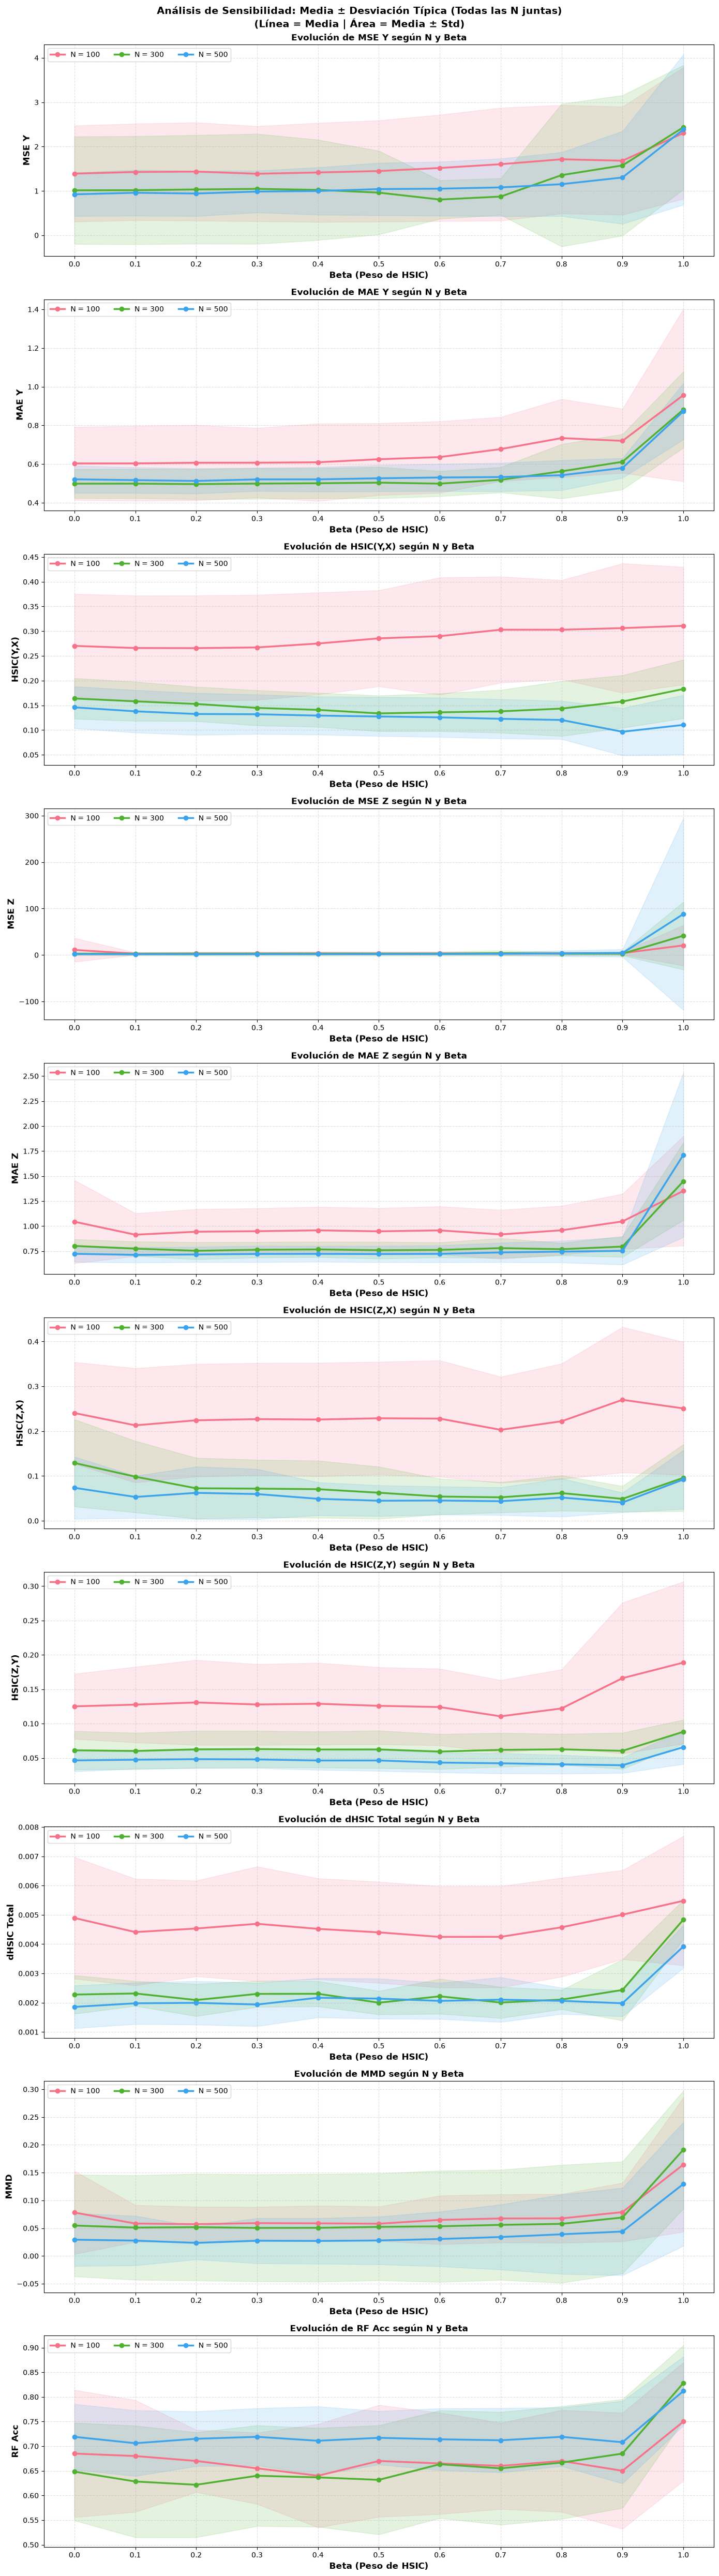

✓ Gráficas generadas con media ± desviación típica (todas las N en una figura)


In [5]:
# ==============================================================================
# PASO 7: VISUALIZACIÓN CON MEDIA ± DESVIACIÓN TÍPICA (BAND PLOTS)
# Todas las N en una misma gráfica, organizadas por Beta
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*100)
print("VISUALIZACIÓN: MEDIA Y DESVIACIÓN TÍPICA POR MÉTRICA")
print("(Línea = Media | Área sombreada = Media ± Desviación Típica)")
print("(Cada color = un tamaño de muestra N diferente)")
print("="*100 + "\n")

# Identificar métricas numéricas
cols_excluidas = {'Experiment', 'Seed', 'Loss', 'Conf', 'Alpha', 'Beta', 'N', 'es_hibrido'}
metricas_para_plot = [col for col in df_final_multi_n.columns if col not in cols_excluidas]

# Crear tabla resumen GLOBAL (todos los N)
resumen_global = []
for n_val in sorted(df_final_multi_n['N'].unique()):
    df_n = df_final_multi_n[df_final_multi_n['N'] == n_val].copy()
    for (alpha, beta), group in df_n.groupby(['Alpha', 'Beta']):
        row = {'N': n_val, 'Alpha': alpha, 'Beta': beta, 'Loss': group['Loss'].iloc[0], 'Conf': group['Conf'].iloc[0]}
        for metrica in metricas_para_plot:
            row[f'{metrica}_mean'] = group[metrica].mean()
            row[f'{metrica}_std'] = group[metrica].std()
        resumen_global.append(row)

df_global = pd.DataFrame(resumen_global)

# Paleta de colores por N
lista_n = sorted(df_global['N'].unique())
colores_n = sns.color_palette("husl", len(lista_n))
paleta_n = dict(zip(lista_n, colores_n))

# Configurar figura con subgráficos (uno por métrica)
num_plots = len(metricas_para_plot)
fig, axes = plt.subplots(num_plots, 1, figsize=(14, 5 * num_plots))
if num_plots == 1:
    axes = [axes]

fig.suptitle('Análisis de Sensibilidad: Media ± Desviación Típica (Todas las N juntas)\n(Línea = Media | Área = Media ± Std)', 
             fontsize=14, fontweight='bold', y=0.995)

# Para cada métrica
for idx, metrica in enumerate(metricas_para_plot):
    ax = axes[idx]
    
    # Para cada N, graficar una línea
    for n_val in sorted(df_global['N'].unique()):
        df_n_data = df_global[df_global['N'] == n_val].sort_values('Beta')
        
        # Extraer valores de media y std
        x = df_n_data['Beta'].values
        y_mean = df_n_data[f'{metrica}_mean'].values
        y_std = df_n_data[f'{metrica}_std'].values
        
        # Calcular límites superiores e inferiores
        y_upper = y_mean + y_std
        y_lower = y_mean - y_std
        
        # Graficar: línea para media y área para std
        color = paleta_n[n_val]
        ax.plot(x, y_mean, marker='o', linewidth=2.5, label=f'N = {n_val}', 
               color=color, markersize=6)
        ax.fill_between(x, y_lower, y_upper, alpha=0.15, color=color)
    
    # Estética
    ax.set_xlabel('Beta (Peso de HSIC)', fontsize=12, fontweight='bold')
    ax.set_ylabel(metrica, fontsize=12, fontweight='bold')
    ax.set_title(f'Evolución de {metrica} según N y Beta', fontsize=12, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc='best', fontsize=10, ncol=3)
    ax.set_xlim(-0.05, 1.05)
    
    # Establecer ticks en X
    ax.set_xticks(sorted(df_global['Beta'].unique()))

plt.tight_layout()

# Guardar figura
if not os.path.exists('plots'):
    os.makedirs('plots')

ruta_plot = os.path.join('plots', 'bandplot_todas_N_aditivo_gamma.png')
plt.savefig(ruta_plot, dpi=300, bbox_inches='tight')
print(f"✓ Gráfica consolidada guardada: {ruta_plot}\n")
plt.show()

print(f"✓ Gráficas generadas con media ± desviación típica (todas las N en una figura)")